<a href="https://colab.research.google.com/github/AbhishekYadav369/sms-spam-detection/blob/main/SMS_Spam_Transformer_Comparison_Combined_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# SMS Spam Detection: BERT vs RoBERTa vs DistilBERT vs ALBERT

This Colab performs a controlled comparison of four Transformer models for SMS spam/ham classification.

### Complete dataset pipeline

`Kaggle SMS dataset → DialMyCalls web scraping → clean + deduplicate → merge → POS tagging → stopword removal → lemmatization → combined train/validation/test split → BERT / RoBERTa / DistilBERT / ALBERT → Accuracy / Precision / Recall / F1-score / ROC-AUC`

**Important:** The Kaggle dataset and the scraped DialMyCalls SMS examples are merged **before** creating the train/validation/test split. Therefore, the four models train, validate, and test on the same combined dataset.

The DialMyCalls examples are retained with a `source` column so the additional data can be audited.


In [ ]:
# =========================
# 1. Install dependencies
# =========================
!pip -q install -U transformers datasets accelerate evaluate scikit-learn spacy beautifulsoup4 requests pandas matplotlib seaborn
!python -m spacy download en_core_web_sm


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 106.4 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [ ]:
import os
import re
import random
import warnings
import numpy as np
import pandas as pd
import torch
import requests
from bs4 import BeautifulSoup

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report, confusion_matrix, roc_curve, auc

import spacy
import matplotlib.pyplot as plt

from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    Trainer,
    TrainingArguments,
    EarlyStoppingCallback,
    set_seed
)

warnings.filterwarnings("ignore")

SEED = 42
set_seed(SEED)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

# Adjust these if your dataset uses different column names.
TEXT_COLUMN = "v2"
LABEL_COLUMN = "v1"

# 0 = ham, 1 = spam
LABEL_MAP = {"ham": 0, "spam": 1}

# Keep this modest for Colab. Increase if you have sufficient GPU RAM.
MAX_LENGTH = 128
NUM_EPOCHS = 3
TRAIN_BATCH_SIZE = 16
EVAL_BATCH_SIZE = 32
LEARNING_RATE = 2e-5
WEIGHT_DECAY = 0.01

MODEL_CONFIGS = {
    "BERT": "bert-base-uncased",
    "RoBERTa": "roberta-base",
    "DistilBERT": "distilbert-base-uncased",
    "ALBERT": "albert-base-v2",
}

Device: cuda
GPU: Tesla T4


## 3. Load the original Kaggle SMS dataset

Upload the original Kaggle `spam.csv` used for the project.

The expected Kaggle format is:

- `v1` → label (`ham` / `spam`)
- `v2` → SMS text

The notebook then standardizes these into:

- `text`
- `label`
- `label_id`
- `source`

The **web-scraped data is NOT loaded separately as a final dataset**. It will be merged with this Kaggle data in the next step, and only then will the combined dataset be split.


In [ ]:
# ============================================================
# 3. Load ORIGINAL KAGGLE SMS DATASET
# ============================================================

from google.colab import files

uploaded = files.upload()

if not uploaded:
    raise ValueError("Please upload the Kaggle spam.csv file.")

uploaded_name = next(iter(uploaded))

kaggle_df = pd.read_csv(
    uploaded_name,
    encoding="latin1"
)

print("Loaded:", uploaded_name)
print("Original Kaggle shape:", kaggle_df.shape)
print("Columns:", kaggle_df.columns.tolist())

# Expected Kaggle SMS Spam Collection format:
# v1 = label
# v2 = SMS message

if not {"v1", "v2"}.issubset(kaggle_df.columns):
    raise ValueError(
        "Expected Kaggle columns 'v1' and 'v2'. "
        f"Found: {kaggle_df.columns.tolist()}"
    )

# Keep only the required columns.
kaggle_df = kaggle_df[["v1", "v2"]].copy()

kaggle_df.columns = ["label", "text"]

kaggle_df["label"] = (
    kaggle_df["label"]
    .astype(str)
    .str.lower()
    .str.strip()
)

kaggle_df["text"] = (
    kaggle_df["text"]
    .astype(str)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

# Convert labels:
# ham  = 0
# spam = 1
kaggle_df["label_id"] = kaggle_df["label"].map(LABEL_MAP)

kaggle_df = kaggle_df.dropna(
    subset=["text", "label_id"]
)

kaggle_df["label_id"] = kaggle_df["label_id"].astype(int)

# Mark the original source.
kaggle_df["source"] = "Kaggle"

print("\nKaggle dataset after basic cleaning:")
print("Rows:", len(kaggle_df))
print(kaggle_df["label"].value_counts())

display(kaggle_df.head())


Saving spam.csv to spam.csv
Loaded: spam.csv
Original Kaggle shape: (5572, 2)
Columns: ['v1', 'v2']

Kaggle dataset after basic cleaning:
Rows: 5572
label
ham     4825
spam     747
Name: count, dtype: int64


,label,text,label_id,source
0,ham,"Go until jurong point, crazy.. Available only ...",0,Kaggle
1,ham,Ok lar... Joking wif u oni...,0,Kaggle
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,1,Kaggle
3,ham,U dun say so early hor... U c already then say...,0,Kaggle
4,ham,"Nah I don't think he goes to usf, he lives aro...",0,Kaggle


## 4. Scrape spam SMS examples from DialMyCalls

The following cell collects examples from:

`https://www.dialmycalls.com/blog/spam-text-message-examples`

The scraped examples are assigned:

`label = spam` and `label_id = 1`

They are **not split or trained separately**. They are merged into the Kaggle dataset first.


In [ ]:
# ============================================================
# DIALMYCALLS WEB SCRAPING CELL
# Source:
# https://www.dialmycalls.com/blog/spam-text-message-examples
#
# Purpose:
# Extract actual SMS examples from DialMyCalls.
# Keep the same column structure as the original dataset.
# The scraped data is merged with the original dataset BEFORE
# train/validation/test splitting.
# ============================================================

import requests
import pandas as pd
import re
from bs4 import BeautifulSoup


# ------------------------------------------------------------
# 1. URL
# ------------------------------------------------------------

URL = (
    "https://www.dialmycalls.com/blog/spam-text-message-examples"
)

HEADERS = {
    "User-Agent": (
        "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
        "AppleWebKit/537.36 (KHTML, like Gecko) "
        "Chrome/154.0 Safari/537.36"
    )
}


# ------------------------------------------------------------
# 2. Download webpage
# ------------------------------------------------------------

response = requests.get(
    URL,
    headers=HEADERS,
    timeout=30
)

response.raise_for_status()

soup = BeautifulSoup(
    response.text,
    "html.parser"
)

print("Webpage successfully downloaded.")


# ------------------------------------------------------------
# 3. Remove unnecessary HTML elements
# ------------------------------------------------------------

for tag in soup.find_all([
    "script",
    "style",
    "noscript",
    "svg",
    "nav",
    "footer",
    "header"
]):
    tag.decompose()


# ------------------------------------------------------------
# 4. Find SMS example headings
# ------------------------------------------------------------

example_headings = soup.find_all(
    lambda tag:
        tag.name in ["h4", "h5", "h6"]
        and "example" in tag.get_text(
            " ",
            strip=True
        ).lower()
)

print(
    "Example sections found:",
    len(example_headings)
)


# ------------------------------------------------------------
# 5. Extract SMS examples
# ------------------------------------------------------------

scraped_messages = []

for heading in example_headings:

    heading_text = heading.get_text(
        " ",
        strip=True
    )

    current = heading.find_next_sibling()

    collected_text = []

    while current:

        # Stop when another heading is reached.
        if current.name in [
            "h2",
            "h3",
            "h4",
            "h5",
            "h6"
        ]:
            break

        if current.name in [
            "p",
            "blockquote",
            "div"
        ]:

            text = current.get_text(
                " ",
                strip=True
            )

            text = re.sub(
                r"\s+",
                " ",
                text
            ).strip()

            if text:
                collected_text.append(text)

        current = current.find_next_sibling()


    # --------------------------------------------------------
    # Select SMS-like text
    # --------------------------------------------------------

    for text in collected_text:

        lower = text.lower()

        unwanted = [
            "why these work",
            "these scams",
            "this scam",
            "these messages",
            "people like",
            "fraudsters",
            "scammers",
            "the goal",
            "the messages"
        ]

        # Ignore explanatory paragraphs.
        if any(
            phrase in lower
            for phrase in unwanted
        ):
            continue

        # Ignore very long paragraphs.
        if len(text) > 350:
            continue

        # Ignore very short fragments.
        if len(text) < 20:
            continue

        scraped_messages.append(text)

        # One SMS example per heading.
        break


# ------------------------------------------------------------
# 6. Create scraped dataframe
# ------------------------------------------------------------

scraped_df = pd.DataFrame(
    {
        "text": scraped_messages
    }
)


# ------------------------------------------------------------
# 7. Clean scraped SMS
# ------------------------------------------------------------

scraped_df["text"] = (
    scraped_df["text"]
    .astype(str)
    .str.replace(
        r"\s+",
        " ",
        regex=True
    )
    .str.strip()
)


# Remove empty messages.
scraped_df = scraped_df[
    scraped_df["text"].str.len() > 0
]


# Remove duplicate SMS.
scraped_df = scraped_df.drop_duplicates(
    subset=["text"]
).reset_index(drop=True)


# ------------------------------------------------------------
# 8. Add the SAME columns used by the original dataset
# ------------------------------------------------------------

# DialMyCalls page contains spam/scam examples.
scraped_df["label"] = "spam"

# 0 = ham
# 1 = spam
scraped_df["label_id"] = 1

# Split is NOT assigned here.
# It will be recreated after merging.

# Identify dataset source.
scraped_df["source"] = "DialMyCalls"


# ------------------------------------------------------------
# 9. Keep EXACT same column order
# ------------------------------------------------------------

scraped_df = scraped_df[
    [
        "text",
        "label",
        "label_id",
        "source"
    ]
]


# ------------------------------------------------------------
# 10. Display scraped dataset
# ------------------------------------------------------------

print("\n==========================================")
print("DIALMYCALLS SCRAPED DATASET")
print("==========================================")

print(
    "Scraped rows:",
    len(scraped_df)
)

print("\nClass distribution:")
print(
    scraped_df["label"].value_counts()
)

print("\nSource distribution:")
print(
    scraped_df["source"].value_counts()
)

display(
    scraped_df.head(20)
)


# ------------------------------------------------------------
# 11. Save scraped dataset
# ------------------------------------------------------------

scraped_df.to_csv(
    "/content/dialmycalls_scraped_spam.csv",
    index=False
)

print(
    "\nSaved:"
    "\n/content/dialmycalls_scraped_spam.csv"
)


# ============================================================
# 12. MERGE WITH ORIGINAL DATASET
# ============================================================

# The original dataframe must already contain:
#
# text
# label
# label_id
# source
# If source is not available, create it.

if "source" not in kaggle_df.columns:
    kaggle_df["source"] = "Original Dataset"


# Keep the SAME columns as scraped_df.
existing_columns = [
    "text",
    "label",
    "label_id",
    "source"
]

df = kaggle_df[existing_columns]


# ------------------------------------------------------------
# Combine original + scraped dataset
# ------------------------------------------------------------

combined_df = pd.concat(
    [
        df,
        scraped_df
    ],
    ignore_index=True
)


# ------------------------------------------------------------
# Normalize text
# ------------------------------------------------------------

combined_df["text"] = (
    combined_df["text"]
    .astype(str)
    .str.replace(
        r"\s+",
        " ",
        regex=True
    )
    .str.strip()
)


# ------------------------------------------------------------
# Normalize labels
# ------------------------------------------------------------

combined_df["label"] = (
    combined_df["label"]
    .astype(str)
    .str.lower()
    .str.strip()
)


combined_df["label_id"] = (
    combined_df["label_id"]
    .astype(int)
)


# ------------------------------------------------------------
# Remove empty messages
# ------------------------------------------------------------

combined_df = combined_df[
    combined_df["text"].str.len() > 0
]


# ------------------------------------------------------------
# Remove duplicate SMS
# ------------------------------------------------------------

combined_df = combined_df.drop_duplicates(
    subset=["text"]
).reset_index(drop=True)

# ============================================================
# 16. SAVE FINAL COMBINED DATASET
# ============================================================

df.to_csv(
    "/content/final_sms_dataset_with_dialmycalls.csv",
    index=False
)


print(
    "\nSaved:"
    "\n/content/final_sms_dataset_with_dialmycalls.csv"
)


print("\nFinal columns:")
print(
    df.columns.tolist()

)
df.shape

Webpage successfully downloaded.
Example sections found: 32

DIALMYCALLS SCRAPED DATASET
Scraped rows: 32

Class distribution:
label
spam    32
Name: count, dtype: int64

Source distribution:
source
DialMyCalls    32
Name: count, dtype: int64


,text,label,label_id,source
0,USPS: Your package is waiting for delivery. Co...,spam,1,DialMyCalls
1,FedEx: Failed delivery attempt. Your package w...,spam,1,DialMyCalls
2,UPS Alert: Package #4829 needs additional info...,spam,1,DialMyCalls
3,"Hi Mum, I lost my phone. Please send money to ...",spam,1,DialMyCalls
4,"Dad, I’m in trouble and need $500 right away. ...",spam,1,DialMyCalls
5,"Hi Mum, I dropped my phone in water. Use this ...",spam,1,DialMyCalls
6,"Grandma, I'm in the hospital after an accident...",spam,1,DialMyCalls
7,Congratulations! You've been selected to recei...,spam,1,DialMyCalls
8,WINNER! You're our 1000th visitor today. Claim...,spam,1,DialMyCalls
9,"URGENT: You've won $5,000 in our monthly drawi...",spam,1,DialMyCalls



Saved:
/content/dialmycalls_scraped_spam.csv

Saved:
/content/final_sms_dataset_with_dialmycalls.csv

Final columns:
['text', 'label', 'label_id', 'source']


(5572, 4)

## 5. Merge Kaggle + web-scraped SMS data

This is the key dataset-construction step.

The order is:

**Kaggle dataset + DialMyCalls dataset → concatenate → clean → remove duplicates → create one combined dataset**

Only after this step will the notebook create the training, validation, and testing sets.

This prevents the four Transformer models from seeing different datasets.


In [ ]:
# ============================================================
# 5. MERGE ORIGINAL KAGGLE + SCRAPED DATASET
# ============================================================

# Combine both datasets BEFORE preprocessing and splitting.
combined_df = pd.concat(
    [
        kaggle_df,
        scraped_df
    ],
    ignore_index=True
)

# Normalize text.
combined_df["text"] = (
    combined_df["text"]
    .astype(str)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

combined_df["label"] = (
    combined_df["label"]
    .astype(str)
    .str.lower()
    .str.strip()
)

combined_df["label_id"] = (
    combined_df["label_id"]
    .astype(int)
)

# Remove exact duplicate SMS messages.
combined_df = combined_df.drop_duplicates(
    subset=["text"]
).reset_index(drop=True)

# Final combined dataset used by the entire experiment.
df = combined_df.copy()

print("==========================================")
print("COMBINED DATASET")
print("==========================================")

print("Kaggle rows:", len(kaggle_df))
print("Scraped rows:", len(scraped_df))
print("Unique combined rows:", len(df))

print("\nClass distribution:")
print(
    df["label"].value_counts()
)

print("\nSource distribution:")
print(
    df["source"].value_counts()
)

display(df.head())

# Save the combined raw dataset BEFORE linguistic preprocessing.
df.to_csv(
    "/content/combined_kaggle_dialmycalls_dataset.csv",
    index=False
)

print(
    "\nSaved: /content/combined_kaggle_dialmycalls_dataset.csv"
)


COMBINED DATASET
Kaggle rows: 5572
Scraped rows: 32
Unique combined rows: 5189

Class distribution:
label
ham     4516
spam     673
Name: count, dtype: int64

Source distribution:
source
Kaggle         5157
DialMyCalls      32
Name: count, dtype: int64


,label,text,label_id,source
0,ham,"Go until jurong point, crazy.. Available only ...",0,Kaggle
1,ham,Ok lar... Joking wif u oni...,0,Kaggle
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,1,Kaggle
3,ham,U dun say so early hor... U c already then say...,0,Kaggle
4,ham,"Nah I don't think he goes to usf, he lives aro...",0,Kaggle



Saved: /content/combined_kaggle_dialmycalls_dataset.csv


## 6. Linguistic preprocessing

The combined Kaggle + DialMyCalls dataset is now processed using:

**POS tagging → stopword removal → lemmatization**

Punctuation and extra whitespace are also removed.

The important point is that preprocessing happens **after merging the two sources but before the final train/validation/test split**.


In [ ]:
# =========================
# 5. spaCy preprocessing
# =========================
nlp = spacy.load("en_core_web_sm", disable=["ner", "parser"])

def preprocess_text(text):
    doc = nlp(text)

    output = []
    for token in doc:
        # POS tagging is performed here; spaCy's POS-aware linguistic analysis
        # is used before lemmatization.
        pos = token.pos_

        # Remove punctuation, spaces, and stopwords.
        if token.is_space or token.is_punct or token.is_stop:
            continue

        lemma = token.lemma_.lower().strip()

        if not lemma or not re.search(r"[a-zA-Z]", lemma):
            continue

        output.append(lemma)

    return " ".join(output)

# Test on a few examples.
for x in df["text"].head(5):
    print("RAW :", x)
    print("PROC:", preprocess_text(x))
    print("-" * 80)


RAW : Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...
PROC: jurong point crazy available bugis n great world la e buffet cine get amore wat
--------------------------------------------------------------------------------
RAW : Ok lar... Joking wif u oni...
PROC: ok lar joke wif u oni
--------------------------------------------------------------------------------
RAW : Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's
PROC: free entry wkly comp win fa cup final tkts 21st text fa receive entry question(std txt rate)t&c apply 08452810075over18
--------------------------------------------------------------------------------
RAW : U dun say so early hor... U c already then say...
PROC: u dun early hor u c
--------------------------------------------------------------------------------
RAW : Nah I don't think he goes to usf

In [ ]:
# Apply preprocessing.
df["processed_text"] = df["text"].apply(preprocess_text)

# Remove messages that become empty after preprocessing.
df = df[df["processed_text"].str.len() > 0].reset_index(drop=True)

print("Processed dataset:", df.shape)
df[["text", "processed_text", "label"]].head(10)


Processed dataset: (5174, 5)


,text,processed_text,label
0,"Go until jurong point, crazy.. Available only ...",jurong point crazy available bugis n great wor...,ham
1,Ok lar... Joking wif u oni...,ok lar joke wif u oni,ham
2,Free entry in 2 a wkly comp to win FA Cup fina...,free entry wkly comp win fa cup final tkts 21s...,spam
3,U dun say so early hor... U c already then say...,u dun early hor u c,ham
4,"Nah I don't think he goes to usf, he lives aro...",nah think go usf live,ham
5,FreeMsg Hey there darling it's been 3 week's n...,freemsg hey darle week word like fun tb ok xxx...,spam
6,Even my brother is not like to speak with me. ...,brother like speak treat like aids patent,ham
7,As per your request 'Melle Melle (Oru Minnamin...,request melle melle oru minnaminunginte nurung...,ham
8,WINNER!! As a valued network customer you have...,winner value network customer select receivea ...,spam
9,Had your mobile 11 months or more? U R entitle...,mobile month u r entitle update late colour mo...,spam


## 7. Create one identical train/validation/test split from the COMBINED dataset

This split is created only after:

1. Kaggle data is loaded.
2. DialMyCalls data is scraped.
3. Both datasets are merged.
4. Duplicate SMS messages are removed.
5. POS tagging, stopword removal, and lemmatization are performed.

All four Transformer models then use exactly the same training, validation, and test records.


In [ ]:
# ============================================================
# 7. FINAL STRATIFIED SPLIT OF COMBINED DATASET
# ============================================================

# 80% training
# 10% validation
# 10% testing

train_df, temp_df = train_test_split(
    df,
    test_size=0.20,
    stratify=df["label"],
    random_state=SEED
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label"],
    random_state=SEED
)

print("==========================================")
print("FINAL DATA SPLIT")
print("==========================================")

print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)

print("\nTrain class distribution:")
print(train_df["label"].value_counts())

print("\nValidation class distribution:")
print(val_df["label"].value_counts())

print("\nTest class distribution:")
print(test_df["label"].value_counts())

print("\nSource distribution by split:")
print(
    pd.crosstab(
        df["split"] if "split" in df.columns else pd.Series(
            ["combined"] * len(df)
        ),
        df["label"]
    )
    if "split" in df.columns
    else "Split column is created below."
)

# Add explicit split information to the combined dataframe.
df["split"] = "unassigned"

df.loc[
    train_df.index,
    "split"
] = "train"

df.loc[
    val_df.index,
    "split"
] = "validation"

df.loc[
    test_df.index,
    "split"
] = "test"

print("\nFinal split counts:")
print(df["split"].value_counts())

print("\nFinal split x class:")
print(
    pd.crosstab(
        df["split"],
        df["label"]
    )
)

# Save the exact dataset used for the experiment.
df.to_csv(
    "/content/final_combined_sms_dataset.csv",
    index=False
)

print(
    "\nSaved: /content/final_combined_sms_dataset.csv"
)


FINAL DATA SPLIT
Train: (4139, 5)
Validation: (517, 5)
Test: (518, 5)

Train class distribution:
label
ham     3601
spam     538
Name: count, dtype: int64

Validation class distribution:
label
ham     450
spam     67
Name: count, dtype: int64

Test class distribution:
label
ham     450
spam     68
Name: count, dtype: int64

Source distribution by split:
Split column is created below.

Final split counts:
split
train         4139
test           518
validation     517
Name: count, dtype: int64

Final split x class:
label        ham  spam
split                 
test         450    68
train       3601   538
validation   450    67

Saved: /content/final_combined_sms_dataset.csv


In [ ]:
# ============================================================
# 8. Convert the FINAL SPLITS to Hugging Face Datasets
# ============================================================

# Ensure labels are mapped to integer values (0 and 1) instead of raw strings
# to prevent tensor conversion errors during training.
train_df_clean = train_df.copy()
val_df_clean = val_df.copy()
test_df_clean = test_df.copy()

train_df_clean["label"] = train_df_clean["label"].map(LABEL_MAP)
val_df_clean["label"] = val_df_clean["label"].map(LABEL_MAP)
test_df_clean["label"] = test_df_clean["label"].map(LABEL_MAP)

train_ds = Dataset.from_pandas(
    train_df_clean[
        ["processed_text", "label"]
    ].rename(
        columns={
            "processed_text": "text"
        }
    ),
    preserve_index=False
)

val_ds = Dataset.from_pandas(
    val_df_clean[
        ["processed_text", "label"]
    ].rename(
        columns={
            "processed_text": "text"
        }
    ),
    preserve_index=False
)

test_ds = Dataset.from_pandas(
    test_df_clean[
        ["processed_text", "label"]
    ].rename(
        columns={
            "processed_text": "text"
        }
    ),
    preserve_index=False
)

print("Train dataset:", train_ds)
print("Validation dataset:", val_ds)
print("Test dataset:", test_ds)
df.head()

Train dataset: Dataset({
    features: ['text', 'label'],
    num_rows: 4139
})
Validation dataset: Dataset({
    features: ['text', 'label'],
    num_rows: 517
})
Test dataset: Dataset({
    features: ['text', 'label'],
    num_rows: 518
})


,label,text,label_id,source,processed_text,split
0,ham,"Go until jurong point, crazy.. Available only ...",0,Kaggle,jurong point crazy available bugis n great wor...,train
1,ham,Ok lar... Joking wif u oni...,0,Kaggle,ok lar joke wif u oni,train
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,1,Kaggle,free entry wkly comp win fa cup final tkts 21s...,train
3,ham,U dun say so early hor... U c already then say...,0,Kaggle,u dun early hor u c,train
4,ham,"Nah I don't think he goes to usf, he lives aro...",0,Kaggle,nah think go usf live,train


## 7. Evaluation function

Every model will be evaluated with the same metrics:

- Accuracy
- Precision
- Recall
- F1-score

For binary spam classification, `spam=1` is treated as the positive class.


In [ ]:
# =========================
# 7. Metrics
# =========================
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)

    accuracy = accuracy_score(labels, predictions)
    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        predictions,
        average="binary",
        zero_division=0
    )

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
    }


## 8. Train and evaluate one Transformer model

The function below is reused for BERT, RoBERTa, DistilBERT, and ALBERT so that the training procedure is as consistent as possible.


In [ ]:

# =========================
# 8. Generic training function
# =========================
def train_and_evaluate(model_name, model_checkpoint):
    print("\n" + "=" * 80)
    print(f"TRAINING: {model_name} ({model_checkpoint})")
    print("=" * 80)

    tokenizer = AutoTokenizer.from_pretrained(model_checkpoint)

    def tokenize(batch):
        return tokenizer(
            batch["text"],
            truncation=True,
            max_length=MAX_LENGTH
        )

    tokenized_train = train_ds.map(tokenize, batched=True, remove_columns=["text"])
    tokenized_val = val_ds.map(tokenize, batched=True, remove_columns=["text"])
    tokenized_test = test_ds.map(tokenize, batched=True, remove_columns=["text"])

    model = AutoModelForSequenceClassification.from_pretrained(
        model_checkpoint,
        num_labels=2,
        id2label={0: "HAM", 1: "SPAM"},
        label2id={"HAM": 0, "SPAM": 1}
    )

    data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

    output_dir = f"/content/{model_name.lower()}_sms_spam"

    training_args = TrainingArguments(
        output_dir=output_dir,
        learning_rate=LEARNING_RATE,
        per_device_train_batch_size=TRAIN_BATCH_SIZE,
        per_device_eval_batch_size=EVAL_BATCH_SIZE,
        num_train_epochs=NUM_EPOCHS,
        weight_decay=WEIGHT_DECAY,
        eval_strategy="epoch",
        save_strategy="epoch",
        load_best_model_at_end=True,
        metric_for_best_model="f1",
        greater_is_better=True,
        logging_strategy="epoch",
        report_to="none",
        fp16=torch.cuda.is_available(),
        seed=SEED
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=tokenized_train,
        eval_dataset=tokenized_val,
        data_collator=data_collator,
        compute_metrics=compute_metrics,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=1)]
    )

    trainer.train()

    test_output = trainer.predict(tokenized_test)

    logits = test_output.predictions
    y_true = test_output.label_ids
    y_pred = np.argmax(logits, axis=-1)

    accuracy = accuracy_score(y_true, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="binary", zero_division=0
    )

    result = {
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1
    }

    print("\nTest metrics:")
    print(pd.DataFrame([result]).to_string(index=False))

    print("\nClassification report:")
    print(classification_report(
        y_true,
        y_pred,
        target_names=["Ham", "Spam"],
        digits=4,
        zero_division=0
    ))

    return result, trainer, tokenizer, y_true, y_pred

## 9. Train the four models

**This is the compute-heavy section.**

On a free Colab GPU, training all four models may take a while. If GPU memory is limited, reduce `TRAIN_BATCH_SIZE` to `8` or `4`, and/or reduce `MAX_LENGTH`.

The four models use the **same processed dataset and same split**.


In [ ]:
# =========================
# 9. Train all four models
# =========================
results = []
artifacts = {}

for model_name, checkpoint in MODEL_CONFIGS.items():
    result, trainer, tokenizer, y_true, y_pred = train_and_evaluate(
        model_name,
        checkpoint
    )

    results.append(result)
    artifacts[model_name] = {
        "trainer": trainer,
        "tokenizer": tokenizer,
        "y_true": y_true,
        "y_pred": y_pred
    }

results_df = pd.DataFrame(results)

# Display percentages for readability.
results_display = results_df.copy()
for col in ["Accuracy", "Precision", "Recall", "F1-Score"]:
    results_display[col] = (results_display[col] * 100).round(2)

results_display



TRAINING: BERT (bert-base-uncased)


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Test metrics:
 Model  Accuracy  Precision   Recall  F1-Score
ALBERT  0.984556   0.954545 0.926471  0.940299

Classification report:
              precision    recall  f1-score   support

         Ham     0.9889    0.9933    0.9911       450
        Spam     0.9545    0.9265    0.9403        68

    accuracy                         0.9846       518
   macro avg     0.9717    0.9599    0.9657       518
weighted avg     0.9844    0.9846    0.9845       518



,Model,Accuracy,Precision,Recall,F1-Score
0,BERT,98.84,98.44,92.65,95.45
1,RoBERTa,98.84,100.00,91.18,95.38
2,DistilBERT,98.84,96.97,94.12,95.52
3,ALBERT,98.46,95.45,92.65,94.03


## 10. Final comparison table

This is the table to use in your experimental results section after the models have actually finished training.


In [ ]:
# =========================
# 10. Final result table
# =========================
results_display = results_df.copy()

for col in ["Accuracy", "Precision", "Recall", "F1-Score"]:
    results_display[col] = (results_display[col] * 100).round(2)

results_display


,Model,Accuracy,Precision,Recall,F1-Score
0,BERT,98.84,98.44,92.65,95.45
1,RoBERTa,98.84,100.00,91.18,95.38
2,DistilBERT,98.84,96.97,94.12,95.52
3,ALBERT,98.46,95.45,92.65,94.03


In [ ]:
# Save the results as CSV.
results_display.to_csv("/content/transformer_sms_spam_results.csv", index=False)

print("Saved: /content/transformer_sms_spam_results.csv")


Saved: /content/transformer_sms_spam_results.csv


## 11. Visual comparison


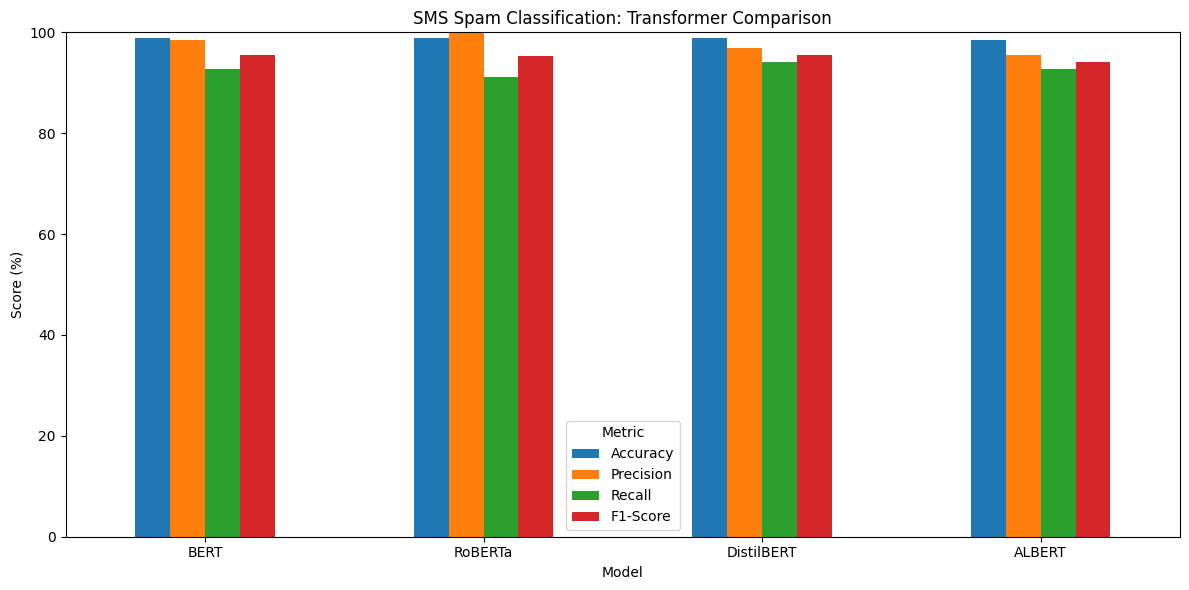

In [ ]:
# =========================
# 11. Metric comparison chart
# =========================
plot_df = results_df.set_index("Model")[["Accuracy", "Precision", "Recall", "F1-Score"]] * 100

ax = plot_df.plot(kind="bar", figsize=(12, 6))
ax.set_title("SMS Spam Classification: Transformer Comparison")
ax.set_ylabel("Score (%)")
ax.set_xlabel("Model")
ax.set_ylim(0, 100)
plt.xticks(rotation=0)
plt.legend(title="Metric")
plt.tight_layout()
plt.show()


## 12. Confusion matrices

A confusion matrix helps distinguish false positives and false negatives, which is important for spam detection.


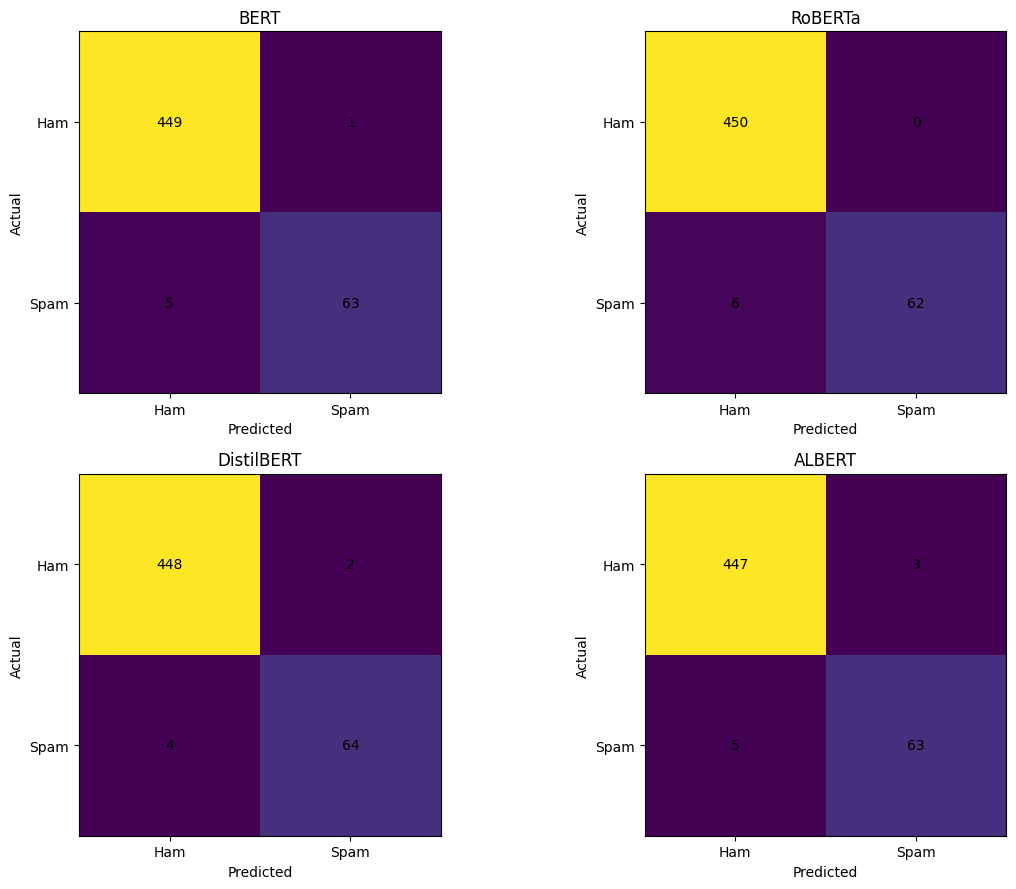

In [ ]:
# =========================
# 12. Confusion matrices
# =========================
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
axes = axes.ravel()

for ax, (model_name, artifact) in zip(axes, artifacts.items()):
    cm = confusion_matrix(
        artifact["y_true"],
        artifact["y_pred"],
        labels=[0, 1]
    )

    im = ax.imshow(cm)
    ax.set_title(model_name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_xticks([0, 1], ["Ham", "Spam"])
    ax.set_yticks([0, 1], ["Ham", "Spam"])

    for i in range(2):
        for j in range(2):
            ax.text(j, i, cm[i, j], ha="center", va="center")

plt.tight_layout()
plt.show()


## 13. Save the trained models

The best model can be selected **after inspecting the measured metrics**. This notebook does not assume in advance which architecture will perform best.

You can save each trained model to the Colab filesystem and optionally copy the folders to Google Drive.


In [ ]:
# =========================
# 13. Save trained model artifacts
# =========================
SAVE_ROOT = "/content/trained_models"
os.makedirs(SAVE_ROOT, exist_ok=True)

for model_name, artifact in artifacts.items():
    path = os.path.join(SAVE_ROOT, model_name.lower())
    artifact["trainer"].save_model(path)
    artifact["tokenizer"].save_pretrained(path)
    print("Saved:", path)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved: /content/trained_models/bert


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved: /content/trained_models/roberta


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved: /content/trained_models/distilbert


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved: /content/trained_models/albert


## 14. Predict a new SMS

After training, use the selected model to classify a new message.


In [ ]:
# =========================
# 14. Inference helper
# =========================
def predict_sms(model_name, sms):
    artifact = artifacts[model_name]
    trainer = artifact["trainer"]
    tokenizer = artifact["tokenizer"]

    processed = preprocess_text(sms)

    inputs = tokenizer(
        processed,
        return_tensors="pt",
        truncation=True,
        max_length=MAX_LENGTH
    )

    # Move tensors to the same device as the model.
    model = trainer.model
    model.eval()
    inputs = {k: v.to(model.device) for k, v in inputs.items()}

    with torch.no_grad():
        logits = model(**inputs).logits
        probabilities = torch.softmax(logits, dim=-1)[0].cpu().numpy()

    pred = int(np.argmax(probabilities))

    return {
        "original_sms": sms,
        "processed_sms": processed,
        "prediction": "SPAM" if pred == 1 else "HAM",
        "ham_probability": float(probabilities[0]),
        "spam_probability": float(probabilities[1])
    }



## ROC–AUC Curves for the Four Transformer Models

This section calculates ROC curves using the **SPAM probability (class 1)** on the same held-out test set.

It produces:
1. One separate ROC curve for BERT.
2. One separate ROC curve for RoBERTa.
3. One separate ROC curve for DistilBERT.
4. One separate ROC curve for ALBERT.
5. One combined ROC plot containing all four models.
6. An AUC summary table.


In [ ]:
# =========================
# ROC–AUC: Calculate curves
# =========================
roc_results = {}

# Recreate the same tokenized test dataset from the fixed test split.
for model_name, artifact in artifacts.items():
    trainer = artifact["trainer"]
    y_true = artifact["y_true"]

    test_for_roc = Dataset.from_pandas(
        test_df[["processed_text", "label_id"]].rename(
            columns={"processed_text": "text", "label_id": "labels"}
        ),
        preserve_index=False
    )

    tokenizer = artifact["tokenizer"]

    def tokenize_roc(batch):
        return tokenizer(
            batch["text"],
            truncation=True,
            max_length=MAX_LENGTH
        )

    tokenized_test_for_roc = test_for_roc.map(
        tokenize_roc,
        batched=True,
        remove_columns=["text"]
    )

    prediction_output = trainer.predict(tokenized_test_for_roc)
    logits = prediction_output.predictions

    # Stable softmax -> probability of SPAM (class 1).
    logits = logits - np.max(logits, axis=1, keepdims=True)
    exp_logits = np.exp(logits)
    probabilities = exp_logits / exp_logits.sum(axis=1, keepdims=True)
    spam_probability = probabilities[:, 1]

    fpr, tpr, thresholds = roc_curve(y_true, spam_probability)
    roc_auc = auc(fpr, tpr)

    roc_results[model_name] = {
        "fpr": fpr,
        "tpr": tpr,
        "thresholds": thresholds,
        "auc": roc_auc,
        "spam_probability": spam_probability,
        "y_true": y_true
    }

    print(f"{model_name}: AUC = {roc_auc:.4f}")


Map:   0%|          | 0/518 [00:00<?, ? examples/s]

BERT: AUC = 0.9890


Map:   0%|          | 0/518 [00:00<?, ? examples/s]

RoBERTa: AUC = 0.9888


Map:   0%|          | 0/518 [00:00<?, ? examples/s]

DistilBERT: AUC = 0.9875


Map:   0%|          | 0/518 [00:00<?, ? examples/s]

ALBERT: AUC = 0.9886


### Separate ROC–AUC curve: BERT


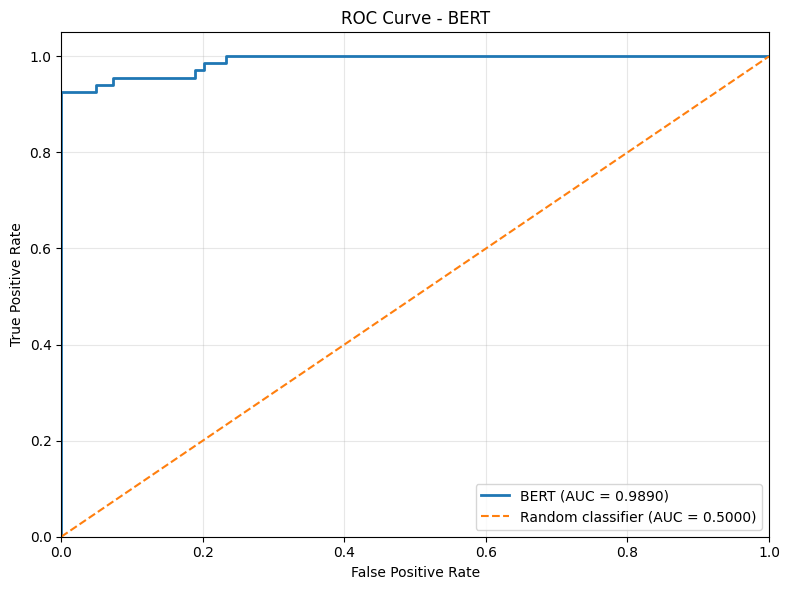

In [ ]:
# =========================
# Separate ROC curve: BERT
# =========================
model_name = "BERT"
r = roc_results[model_name]

plt.figure(figsize=(8, 6))
plt.plot(r["fpr"], r["tpr"], linewidth=2,
         label=f'{model_name} (AUC = {r["auc"]:.4f})')
plt.plot([0, 1], [0, 1], linestyle="--", linewidth=1.5,
         label="Random classifier (AUC = 0.5000)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - BERT")
plt.xlim(0, 1)
plt.ylim(0, 1.05)
plt.grid(alpha=0.3)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()


### Separate ROC–AUC curve: RoBERTa


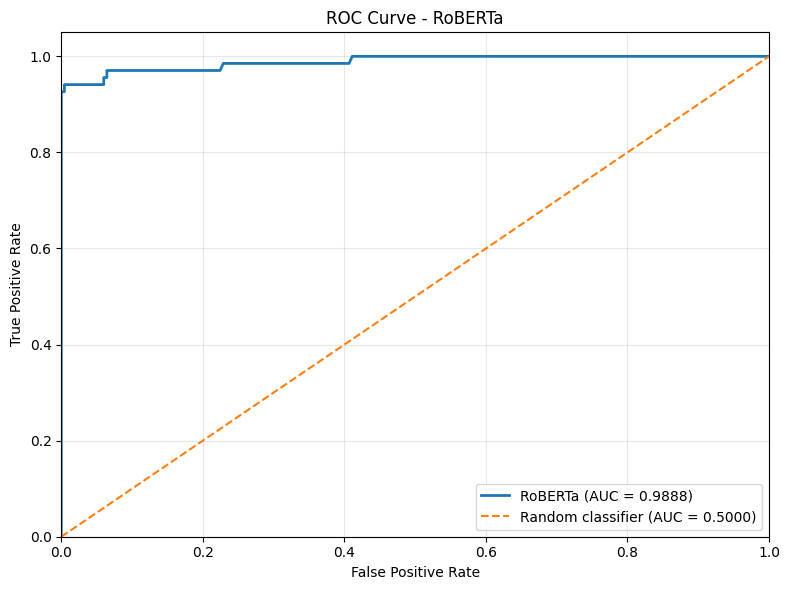

In [ ]:
# =========================
# Separate ROC curve: RoBERTa
# =========================
model_name = "RoBERTa"
r = roc_results[model_name]

plt.figure(figsize=(8, 6))
plt.plot(r["fpr"], r["tpr"], linewidth=2,
         label=f'{model_name} (AUC = {r["auc"]:.4f})')
plt.plot([0, 1], [0, 1], linestyle="--", linewidth=1.5,
         label="Random classifier (AUC = 0.5000)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - RoBERTa")
plt.xlim(0, 1)
plt.ylim(0, 1.05)
plt.grid(alpha=0.3)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()


### Separate ROC–AUC curve: DistilBERT


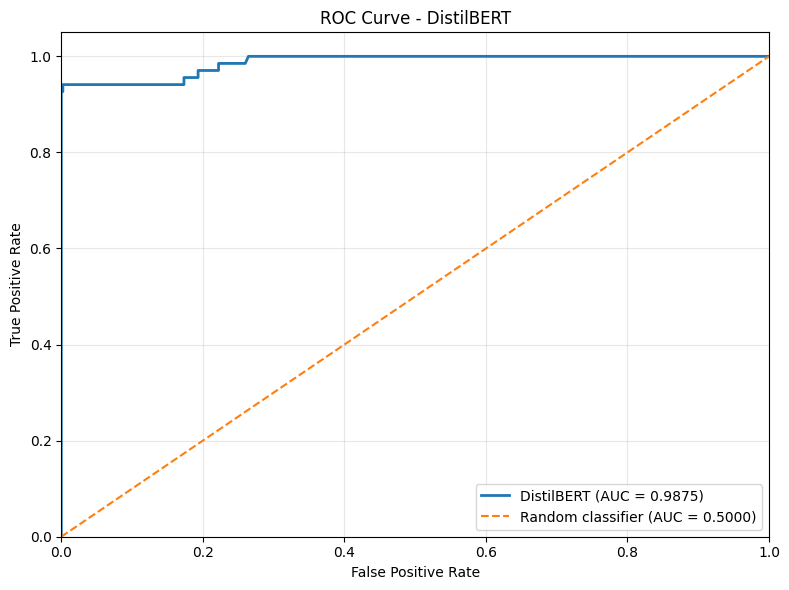

In [ ]:
# =========================
# Separate ROC curve: DistilBERT
# =========================
model_name = "DistilBERT"
r = roc_results[model_name]

plt.figure(figsize=(8, 6))
plt.plot(r["fpr"], r["tpr"], linewidth=2,
         label=f'{model_name} (AUC = {r["auc"]:.4f})')
plt.plot([0, 1], [0, 1], linestyle="--", linewidth=1.5,
         label="Random classifier (AUC = 0.5000)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - DistilBERT")
plt.xlim(0, 1)
plt.ylim(0, 1.05)
plt.grid(alpha=0.3)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()


### Separate ROC–AUC curve: ALBERT


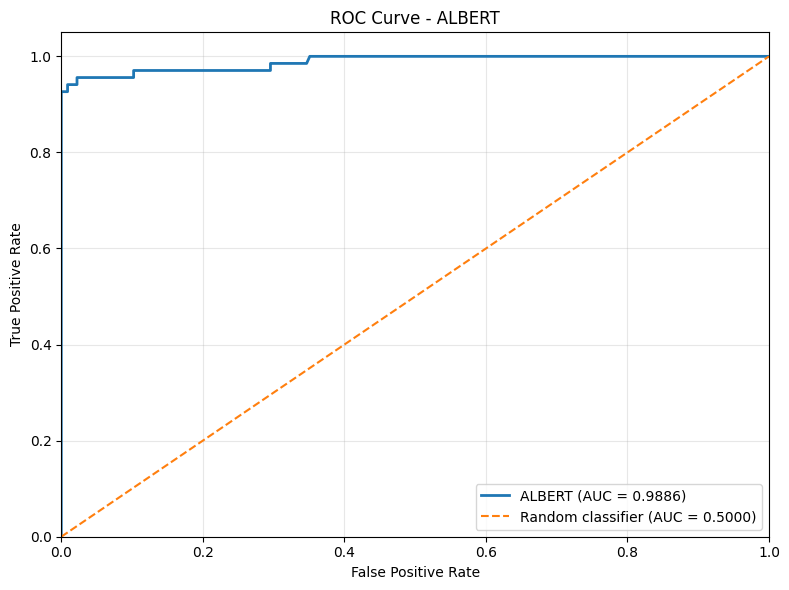

In [ ]:
# =========================
# Separate ROC curve: ALBERT
# =========================
model_name = "ALBERT"
r = roc_results[model_name]

plt.figure(figsize=(8, 6))
plt.plot(r["fpr"], r["tpr"], linewidth=2,
         label=f'{model_name} (AUC = {r["auc"]:.4f})')
plt.plot([0, 1], [0, 1], linestyle="--", linewidth=1.5,
         label="Random classifier (AUC = 0.5000)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - ALBERT")
plt.xlim(0, 1)
plt.ylim(0, 1.05)
plt.grid(alpha=0.3)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()


### Combined ROC–AUC curve: all four models


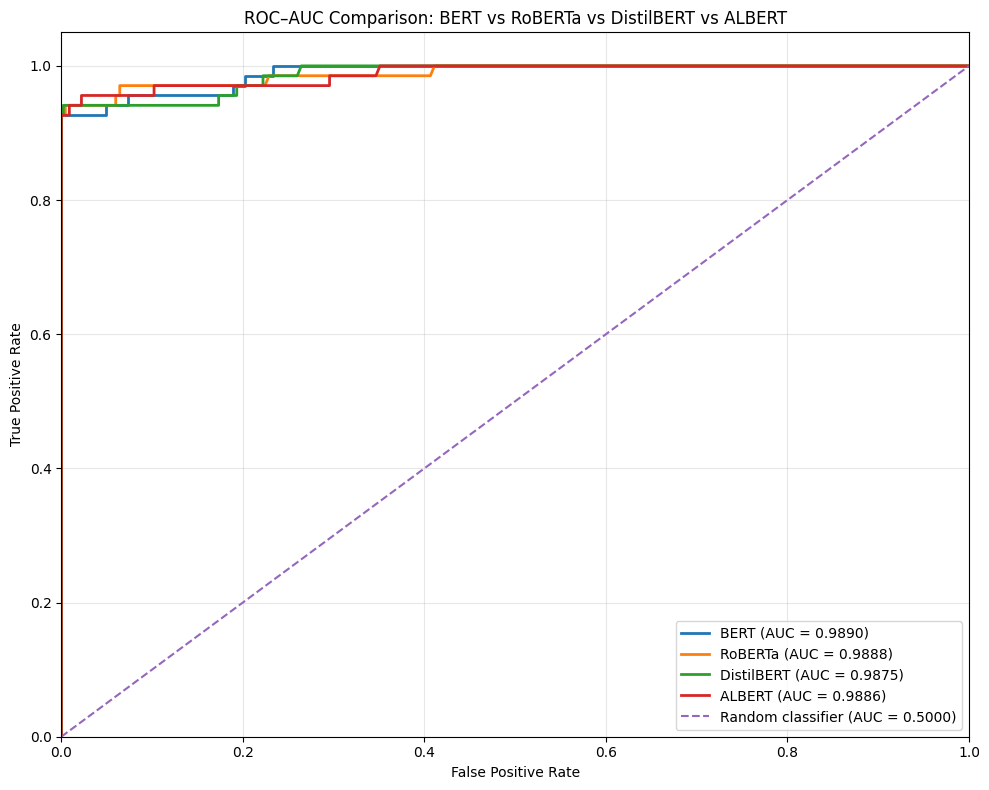

In [ ]:
# =========================
# Combined ROC curves
# =========================
plt.figure(figsize=(10, 8))

for model_name, r in roc_results.items():
    plt.plot(
        r["fpr"],
        r["tpr"],
        linewidth=2,
        label=f'{model_name} (AUC = {r["auc"]:.4f})'
    )

plt.plot([0, 1], [0, 1], linestyle="--", linewidth=1.5,
         label="Random classifier (AUC = 0.5000)")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC–AUC Comparison: BERT vs RoBERTa vs DistilBERT vs ALBERT")
plt.xlim(0, 1)
plt.ylim(0, 1.05)
plt.grid(alpha=0.3)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()


### AUC summary table


In [ ]:
# =========================
# AUC summary table
# =========================
auc_results = pd.DataFrame([
    {"Model": model_name, "AUC": r["auc"]}
    for model_name, r in roc_results.items()
])

auc_results["AUC"] = auc_results["AUC"].round(4)
auc_results


,Model,AUC
0,BERT,0.9890
1,RoBERTa,0.9888
2,DistilBERT,0.9875
3,ALBERT,0.9886


## Cross Verifying the model by using new sms message
- BERT: "bert-base-uncased"
- RoBERTa : "roberta-base"
- DistilBERT : "distilbert-base-uncased"
- ALBERT : "albert-base-v2".

In [ ]:
import os
import re
import torch
import numpy as np
import spacy
from transformers import AutoTokenizer, AutoModelForSequenceClassification

# Initialize spaCy and preprocess_text inline to make the cell self-contained
nlp = spacy.load("en_core_web_sm", disable=["ner", "parser"])
MAX_LENGTH = 128

def preprocess_text(text):
    doc = nlp(text)
    output = []
    for token in doc:
        # Remove punctuation, spaces, and stopwords
        if token.is_space or token.is_punct or token.is_stop:
            continue
        lemma = token.lemma_.lower().strip()
        if not lemma or not re.search(r"[a-zA-Z]", lemma):
            continue
        output.append(lemma)
    return " ".join(output)

# Helper function that loads saved models directly from disk
def predict_sms_from_disk(model_name, sms):
    model_path = os.path.join("/content/trained_models", model_name.lower())

    if not os.path.exists(model_path):
        raise FileNotFoundError(f"Saved model path not found at {model_path}. Please ensure training completed.")

    # Load tokenizer and model directly from the saved directory
    tokenizer = AutoTokenizer.from_pretrained(model_path)
    model = AutoModelForSequenceClassification.from_pretrained(model_path)

    # Preprocess text
    processed = preprocess_text(sms)

    inputs = tokenizer(
        processed,
        return_tensors="pt",
        truncation=True,
        max_length=MAX_LENGTH
    )

    # Run inference
    device = "cuda" if torch.cuda.is_available() else "cpu"
    model = model.to(device)
    model.eval()
    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        logits = model(**inputs).logits
        probabilities = torch.softmax(logits, dim=-1)[0].cpu().numpy()

    pred = int(np.argmax(probabilities))

    return {
        "original_sms": sms,
        "processed_sms": processed,
        "prediction": "SPAM" if pred == 1 else "HAM",
        "ham_probability": float(probabilities[0]),
        "spam_probability": float(probabilities[1])
    }

# Cross-verify using the saved RoBERTa model
prediction = predict_sms_from_disk(
    "RoBERTa",
    "Congratulations! You have won a free prize. Click here now!"
)
prediction

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

{'original_sms': 'Congratulations! You have won a free prize. Click here now!',
 'processed_sms': 'congratulation win free prize click',
 'prediction': 'SPAM',
 'ham_probability': 0.0014878557994961739,
 'spam_probability': 0.9985120892524719}

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Research reporting checklist

For your report/paper, record:

1. Dataset name and total number of SMS messages.
2. Number of ham and spam messages.
3. Web sources, URLs, collection date, and reuse/license information if scraping was used.
4. Duplicate-removal procedure.
5. POS tagging, stopword removal, and lemmatization method.
6. Exact train/validation/test split and random seed.
7. Model checkpoints/versions.
8. Number of epochs, learning rate, batch size, and maximum sequence length.
9. Accuracy, precision, recall, and F1-score for all four models.
10. Confusion matrix for each model.
11. Hardware used, such as Colab GPU type.
12. A separate baseline experiment with minimal preprocessing if possible.

### Final result table format

| Model | Accuracy | Precision | Recall | F1-Score |
|---|---:|---:|---:|---:|
| BERT | measured | measured | measured | measured |
| RoBERTa | measured | measured | measured | measured |
| DistilBERT | measured | measured | measured | measured |
| ALBERT | measured | measured | measured | measured |

**Do not replace the measured values with expected or invented scores.**


In [ ]:
import os
import pickle
import json

# ------------------------------------------------------------
# 1. Mount Google Drive
# ------------------------------------------------------------

# drive.mount("/content/drive")


# ------------------------------------------------------------
# 2. Create permanent model directory
# ------------------------------------------------------------

BASE_DIR = (
    "/content/drive/MyDrive/"
    "SMS_Spam_Models"
)

os.makedirs(
    BASE_DIR,
    exist_ok=True
)


# ------------------------------------------------------------
# 3. Model information
# ------------------------------------------------------------

trained_models = {
    "bert": {
        "trainer": artifacts["BERT"]["trainer"],
        "tokenizer": artifacts["BERT"]["tokenizer"]
    },

    "roberta": {
        "trainer": artifacts["RoBERTa"]["trainer"],
        "tokenizer": artifacts["RoBERTa"]["tokenizer"]
    },

    "distilbert": {
        "trainer": artifacts["DistilBERT"]["trainer"],
        "tokenizer": artifacts["DistilBERT"]["tokenizer"]
    },

    "albert": {
        "trainer": artifacts["ALBERT"]["trainer"],
        "tokenizer": artifacts["ALBERT"]["tokenizer"]
    }
}


# ------------------------------------------------------------
# 4. Save each model + tokenizer
# ------------------------------------------------------------

for model_name, objects in trained_models.items():

    model_dir = os.path.join(
        BASE_DIR,
        model_name
    )

    os.makedirs(
        model_dir,
        exist_ok=True
    )

    # Save trained model
    objects["trainer"].save_model(
        model_dir
    )

    # Save tokenizer
    objects["tokenizer"].save_pretrained(
        model_dir
    )

    print(
        f"{model_name.upper()} saved successfully."
    )


# ------------------------------------------------------------
# 5. Save label mapping
# ------------------------------------------------------------

label_mapping = {
    0: "ham",
    1: "spam"
}

with open(
    os.path.join(
        BASE_DIR,
        "label_mapping.pkl"
    ),
    "wb"
) as file:

    pickle.dump(
        label_mapping,
        file
    )


# ------------------------------------------------------------
# 6. Save experiment information
# ------------------------------------------------------------

experiment_info = {
    "task": "SMS Spam Classification",

    "models": [
        "BERT",
        "RoBERTa",
        "DistilBERT",
        "ALBERT"
    ],

    "label_mapping": {
        "0": "ham",
        "1": "spam"
    },

    "max_length": 128,

    "dataset_split": {
        "train": 0.80,
        "validation": 0.10,
        "test": 0.10
    },

    "random_state": 42
}

with open(
    os.path.join(
        BASE_DIR,
        "experiment_info.json"
    ),
    "w"
) as file:

    json.dump(
        experiment_info,
        file,
        indent=4
    )


# ------------------------------------------------------------
# 7. Final confirmation
# ------------------------------------------------------------

print("\n==========================================")
print("ALL MODELS SAVED SUCCESSFULLY")
print("==========================================")

print(
    f"\nLocation:\n{BASE_DIR}"
)

print("\nSaved models:")

for model_name in trained_models:
    print(
        f"  ✓ {model_name.upper()}"
    )

print("\nAdditional files:")
print("  ✓ label_mapping.pkl")
print("  ✓ experiment_info.json")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

BERT saved successfully.


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

ROBERTA saved successfully.


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

DISTILBERT saved successfully.


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

ALBERT saved successfully.

ALL MODELS SAVED SUCCESSFULLY

Location:
/content/drive/MyDrive/SMS_Spam_Models

Saved models:
  ✓ BERT
  ✓ ROBERTA
  ✓ DISTILBERT
  ✓ ALBERT

Additional files:
  ✓ label_mapping.pkl
  ✓ experiment_info.json


## Later: load the trained models

### After you restart Colab, run this cell

In [ ]:
# ============================================================
# LOAD SAVED SMS SPAM MODELS
# ============================================================

from google.colab import drive
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification
)

import os
import pickle
import torch

# ------------------------------------------------------------
# 1. Mount Google Drive
# ------------------------------------------------------------

drive.mount("/content/drive")


# ------------------------------------------------------------
# 2. Model directory
# ------------------------------------------------------------

BASE_DIR = (
    "/content/drive/MyDrive/"
    "SMS_Spam_Models"
)


# ------------------------------------------------------------
# 3. Load label mapping
# ------------------------------------------------------------

with open(
    os.path.join(
        BASE_DIR,
        "label_mapping.pkl"
    ),
    "rb"
) as file:

    label_mapping = pickle.load(file)


print(
    "Label mapping:",
    label_mapping
)


# ------------------------------------------------------------
# 4. Load all four models
# ------------------------------------------------------------

MODEL_NAMES = [
    "bert",
    "roberta",
    "distilbert",
    "albert"
]

models = {}
tokenizers = {}


for model_name in MODEL_NAMES:

    model_dir = os.path.join(
        BASE_DIR,
        model_name
    )

    # Load tokenizer
    tokenizers[model_name] = (
        AutoTokenizer.from_pretrained(
            model_dir
        )
    )

    # Load trained model
    models[model_name] = (
        AutoModelForSequenceClassification
        .from_pretrained(
            model_dir
        )
    )

    # Evaluation mode
    models[model_name].eval()

    print(
        f"{model_name.upper()} loaded successfully."
    )


print("\n==========================================")
print("ALL FOUR MODELS LOADED")
print("==========================================")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Label mapping: {0: 'ham', 1: 'spam'}


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BERT loaded successfully.


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

ROBERTA loaded successfully.


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

DISTILBERT loaded successfully.


Loading weights:   0%|          | 0/27 [00:00<?, ?it/s]

ALBERT loaded successfully.

ALL FOUR MODELS LOADED


## Final verification cell

### Now you can enter any new SMS and verify it against all four trained models:

In [ ]:
# ============================================================
# VERIFY NEW SMS USING ALL FOUR MODELS
# ============================================================

def predict_sms_all_models(text):

    results = []

    for model_name in MODEL_NAMES:

        tokenizer = tokenizers[model_name]
        model = models[model_name]

        # Tokenize SMS
        inputs = tokenizer(
            text,
            return_tensors="pt",
            truncation=True,
            padding=True,
            max_length=128
        )

        # Prediction
        with torch.no_grad():

            outputs = model(**inputs)

            probabilities = torch.softmax(
                outputs.logits,
                dim=1
            )

            prediction = torch.argmax(
                probabilities,
                dim=1
            ).item()

        label = label_mapping[prediction]

        confidence = (
            probabilities[0][prediction]
            .item()
        )

        results.append({
            "Model": model_name.upper(),
            "Prediction": label,
            "Confidence": round(
                confidence * 100,
                2
            )
        })

    return pd.DataFrame(results)

In [ ]:
sms = (
    "Congratulations! You have won "
    "a cash prize. Click the link to claim now."
)

results = predict_sms_all_models(sms)

display(results)

,Model,Prediction,Confidence
0,BERT,spam,97.58
1,ROBERTA,spam,98.80
2,DISTILBERT,ham,64.30
3,ALBERT,spam,99.15
